In [ ]:
import os

# Carga credenciales desde variables de entorno del sistema.
# Evita guardar claves sensibles en el notebook.
os.environ["KAGGLE_USERNAME"] = os.getenv("KAGGLE_USERNAME", "")
os.environ["KAGGLE_KEY"] = os.getenv("KAGGLE_KEY", "")

if not os.environ["KAGGLE_USERNAME"] or not os.environ["KAGGLE_KEY"]:
    print("Credenciales de Kaggle no definidas en variables de entorno.")

In [23]:
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install tensorflow

ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


In [4]:
%pip install -U pip
%pip install numpy pandas matplotlib seaborn librosa soundfile

Note: you may need to restart the kernel to use updated packages.
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 5.7 MB/s  0:00:026m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 5.7 MB/s  0:00:016m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 1.1 MB/s  0:00:086m0:00:0100:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 615.1 kB/s  0:00:010:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 1.2 MB/s  0:00:03m eta 0:0

# Exploración de Datos - Voice Commands Classification 2026

## Análisis Exploratorio del Dataset de Kaggle
Este notebook realiza un análisis exhaustivo del dataset de clasificación de comandos de voz de la competición Voice Commands Classification 2026 de Kaggle.

**Objetivos:**
- Cargar y explorar la estructura del dataset
- Analizar las características de los archivos de audio
- Examinar la distribución de clases
- Evaluar la calidad de los datos
- Identificar patrones y anomalías

## 1. Importación de Librerías Requeridas

In [1]:
# Importar librerías estándar
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter, defaultdict
import shutil

# Importar librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Importar librerías para procesamiento de audio
try:
    import librosa
    import librosa.display
    import soundfile as sf
except ImportError:
    print("librosa o soundfile no están instaladas. Instalando...")
    os.system('pip install librosa soundfile')
    import librosa
    import librosa.display
    import soundfile as sf

# Configurar estilo de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore')

## 2. Carga y Exploración de la Estructura del Dataset

In [2]:
# Definir rutas de datos
# Nota: Ajusta estas rutas según la ubicación de tus datos descargados
DATA_PATH = Path('./data')
TRAIN_DIR = DATA_PATH / 'train/train/train/'
TEST_DIR = DATA_PATH / 'adv_test/'

# Verificar si los directorios existen
print("Verificando rutas de datos...")
print(f"Ruta de datos: {DATA_PATH}")
print(f"¿Existe DATA_PATH?: {DATA_PATH.exists()}")
print(f"¿Existe TRAIN_DIR?: {TRAIN_DIR.exists()}")
print(f"¿Existe TEST_DIR?: {TEST_DIR.exists()}")

# Crear estructura de análisis
if DATA_PATH.exists():
    print("\n📁 Estructura de directorios:")
    for root, dirs, files in os.walk(DATA_PATH):
        level = root.replace(str(DATA_PATH), '').count(os.sep)
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        sub_indent = ' ' * 2 * (level + 1)
        for file in files[:5]:  # Mostrar primeros 5 archivos
            print(f'{sub_indent}{file}')
        if len(files) > 5:
            print(f'{sub_indent}... y {len(files) - 5} archivos más')
else:
    print("\n⚠️ Advertencia: No se encontró la carpeta 'data'. Por favor, descarga los datos de Kaggle.")
    print("   Descargalos en: /home/michael/jupyter-gemini/notebooks/dl_voice_command_cl/data")

Verificando rutas de datos...
Ruta de datos: data
¿Existe DATA_PATH?: True
¿Existe TRAIN_DIR?: True
¿Existe TEST_DIR?: True

📁 Estructura de directorios:
data/
  adv_test/
    30469.npy
    96497.npy
    82345.npy
    48661.npy
    12789.npy
    ... y 10573 archivos más
  train/
    train/
      train/
        13346.npy
        53042.npy
        90363.npy
        35194.npy
        89878.npy
        ... y 95242 archivos más


In [6]:
# ==============================
# FUNCIÓN OPTIMIZADA POR ARCHIVO
# ==============================
def process_file(file_path, infer_class=True):
    try:
        file_ext = file_path.suffix.lower()
        file_size = file_path.stat().st_size
        command_class = file_path.parent.name if infer_class else None

        # Defaults
        duration = np.nan
        sample_rate = np.nan
        num_samples = np.nan
        num_channels = np.nan
        array_shape = None
        array_dtype = None

        if file_ext in ('.npy', '.npz'):
            obj = np.load(file_path, mmap_mode='r', allow_pickle=False)

            if isinstance(obj, np.lib.npyio.NpzFile):
                keys = list(obj.files)
                array_shape = {k: tuple(obj[k].shape) for k in keys}
                array_dtype = {k: str(obj[k].dtype) for k in keys}

                candidate_key = 'audio' if 'audio' in keys else keys[0]
                arr = obj[candidate_key]
            else:
                arr = obj
                array_shape = tuple(arr.shape)
                array_dtype = str(arr.dtype)

            if isinstance(arr, np.ndarray):
                if arr.ndim == 1:
                    num_samples = arr.shape[0]
                    num_channels = 1
                else:
                    num_samples = max(arr.shape)
                    num_channels = min(arr.shape)

        return {
            'file_path': str(file_path),
            'filename': file_path.name,
            'extension': file_ext,
            'class': command_class,
            'duration': duration,
            'sample_rate': sample_rate,
            'num_samples': num_samples,
            'num_channels': num_channels,
            'array_shape': str(array_shape),
            'array_dtype': str(array_dtype),
            'file_size_bytes': file_size,
            'file_size_mb': file_size / (1024 * 1024)
        }

    except Exception:
        return None


# ==============================
# ESCANEO PARALELIZADO
# ==============================
def scan_dataset_fast(directory, infer_class=True, max_workers=8):
    if not directory.exists():
        print(f"❌ No existe: {directory}")
        return pd.DataFrame()

    valid_ext = ('.npy', '.npz')
    file_list = []

    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(valid_ext):
                file_list.append(Path(root) / file)

    print(f"📂 Archivos encontrados en {directory}: {len(file_list)}")

    results = []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(process_file, f, infer_class) for f in file_list]

        for i, future in enumerate(as_completed(futures)):
            res = future.result()
            if res:
                results.append(res)

            if i % 5000 == 0 and i > 0:
                print(f"Procesados: {i}/{len(file_list)}")

    return pd.DataFrame(results)


# ==============================
# EJECUCIÓN
# ==============================
print("\n🚀 Escaneando dataset (optimizado)...")

train_df = scan_dataset_fast(TRAIN_DIR, infer_class=True, max_workers=8)
test_df = scan_dataset_fast(TEST_DIR, infer_class=False, max_workers=8)

# ==============================
# RESULTADOS
# ==============================
print("\n📊 RESULTADOS")
print(f"Train samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")

if len(train_df) > 0:
    print("\nExtensiones:")
    print(train_df['extension'].value_counts())

    print("\nPrimeras filas:")
    print(train_df.head())

    print("\nEstadísticas básicas:")
    print(train_df[['num_samples', 'file_size_mb']].describe())


🚀 Escaneando dataset (optimizado)...
📂 Archivos encontrados en data/train/train/train: 95246
Procesados: 5000/95246
Procesados: 10000/95246
Procesados: 15000/95246
Procesados: 20000/95246
Procesados: 25000/95246
Procesados: 30000/95246
Procesados: 35000/95246
Procesados: 40000/95246
Procesados: 45000/95246
Procesados: 50000/95246
Procesados: 55000/95246
Procesados: 60000/95246
Procesados: 65000/95246
Procesados: 70000/95246
Procesados: 75000/95246
Procesados: 80000/95246
Procesados: 85000/95246
Procesados: 90000/95246
Procesados: 95000/95246
📂 Archivos encontrados en data/adv_test: 10576
Procesados: 5000/10576
Procesados: 10000/10576

📊 RESULTADOS
Train samples: 95246
Test samples: 10576

Extensiones:
extension
.npy    95246
Name: count, dtype: int64

Primeras filas:
                          file_path   filename extension  class  duration  \
0  data/train/train/train/53042.npy  53042.npy      .npy  train       NaN   
1  data/train/train/train/95649.npy  95649.npy      .npy  train    

## 3. Análisis Exploratorio de Datos (EDA)

In [10]:
if len(train_df) > 0:
    print("=" * 60)
    print("📊 INFORMACIÓN GENERAL DEL DATASET")
    print("=" * 60)
    
    print(f"\nForma del dataset: {train_df.shape}")
    print(f"Número de columnas: {len(train_df.columns)}")
    print(f"Tipos de datos:\n{train_df.dtypes}")
    
    print("\n" + "=" * 60)
    print("📈 ESTADÍSTICAS DESCRIPTIVAS")
    print("=" * 60)
    print(train_df.describe())
    
    print("\n" + "=" * 60)
    print("🔍 INFORMACIÓN DE VALORES NULOS")
    print("=" * 60)
    print(f"Valores nulos por columna:\n{train_df.isnull().sum()}")
    
    print("\n" + "=" * 60)
    print("🎤 INFORMACIÓN DE CLASES (COMANDOS DE VOZ)")
    print("=" * 60)
    class_counts = train_df['class'].value_counts()
    print(f"\nNúmero de clases: {len(class_counts)}")
    print(f"\nDistribución de clases:")
    print(class_counts)
else:
    print("⚠️ No hay datos de entrenamiento disponibles. Por favor, descarga el dataset de Kaggle.")

📊 INFORMACIÓN GENERAL DEL DATASET

Forma del dataset: (95246, 12)
Número de columnas: 12
Tipos de datos:
file_path              str
filename               str
extension              str
class                  str
duration           float64
sample_rate        float64
num_samples          int64
num_channels         int64
array_shape            str
array_dtype            str
file_size_bytes      int64
file_size_mb       float64
dtype: object

📈 ESTADÍSTICAS DESCRIPTIVAS
       duration  sample_rate   num_samples  num_channels  file_size_bytes  \
count       0.0          0.0  95246.000000       95246.0     95246.000000   
mean        NaN          NaN  15693.335626           1.0     62901.342503   
std         NaN          NaN   1151.195458           0.0      4604.781833   
min         NaN          NaN   3413.000000           1.0     13780.000000   
25%         NaN          NaN  16000.000000           1.0     64128.000000   
50%         NaN          NaN  16000.000000           1.0     64128

## 4. Análisis de Señales Orientado a CNN

ANALISIS DE LONGITUD DE SENAL PARA CNN
Total muestras con num_samples: 95246
Min: 3413
Max: 16000
Percentiles:
0.50    16000.0
0.90    16000.0
0.95    16000.0
0.99    16000.0
Name: num_samples, dtype: float64

num_samples objetivo sugerido (p95): 16000


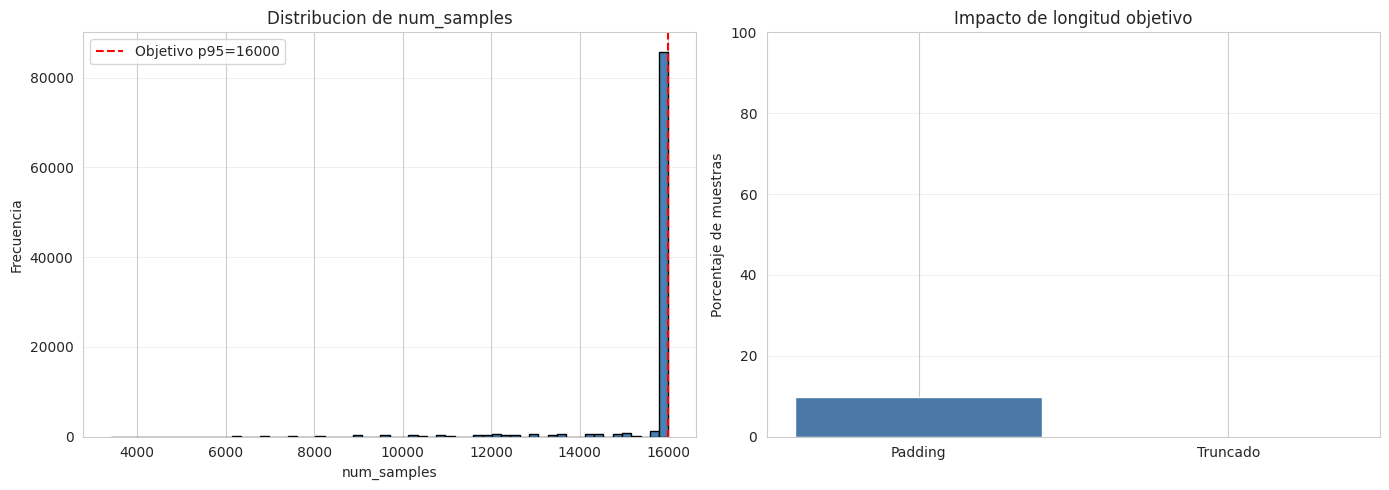

In [16]:
if len(train_df) > 0:
    print("=" * 60)
    print("ANALISIS DE LONGITUD DE SENAL PARA CNN")
    print("=" * 60)

    valid_samples = train_df['num_samples'].dropna()

    if len(valid_samples) == 0:
        print("No hay valores de num_samples para analizar.")
    else:
        print(f"Total muestras con num_samples: {len(valid_samples)}")
        print(f"Min: {valid_samples.min():.0f}")
        print(f"Max: {valid_samples.max():.0f}")

        percentiles = valid_samples.quantile([0.5, 0.9, 0.95, 0.99])
        print("Percentiles:")
        print(percentiles)

        target_num_samples = int(percentiles.loc[0.95])
        print(f"\nnum_samples objetivo sugerido (p95): {target_num_samples}")

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].hist(valid_samples, bins=60, color='steelblue', edgecolor='black')
        axes[0].axvline(target_num_samples, color='red', linestyle='--', label=f'Objetivo p95={target_num_samples}')
        axes[0].set_title('Distribucion de num_samples')
        axes[0].set_xlabel('num_samples')
        axes[0].set_ylabel('Frecuencia')
        axes[0].legend()
        axes[0].grid(axis='y', alpha=0.3)

        padded_ratio = (valid_samples < target_num_samples).mean() * 100
        truncated_ratio = (valid_samples > target_num_samples).mean() * 100

        axes[1].bar(['Padding', 'Truncado'], [padded_ratio, truncated_ratio], color=['#4c78a8', '#f58518'])
        axes[1].set_title('Impacto de longitud objetivo')
        axes[1].set_ylabel('Porcentaje de muestras')
        axes[1].set_ylim(0, 100)
        axes[1].grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.show()
else:
    print("No hay datos disponibles para analizar.")


Visualizacion de muestras .npy/.npz


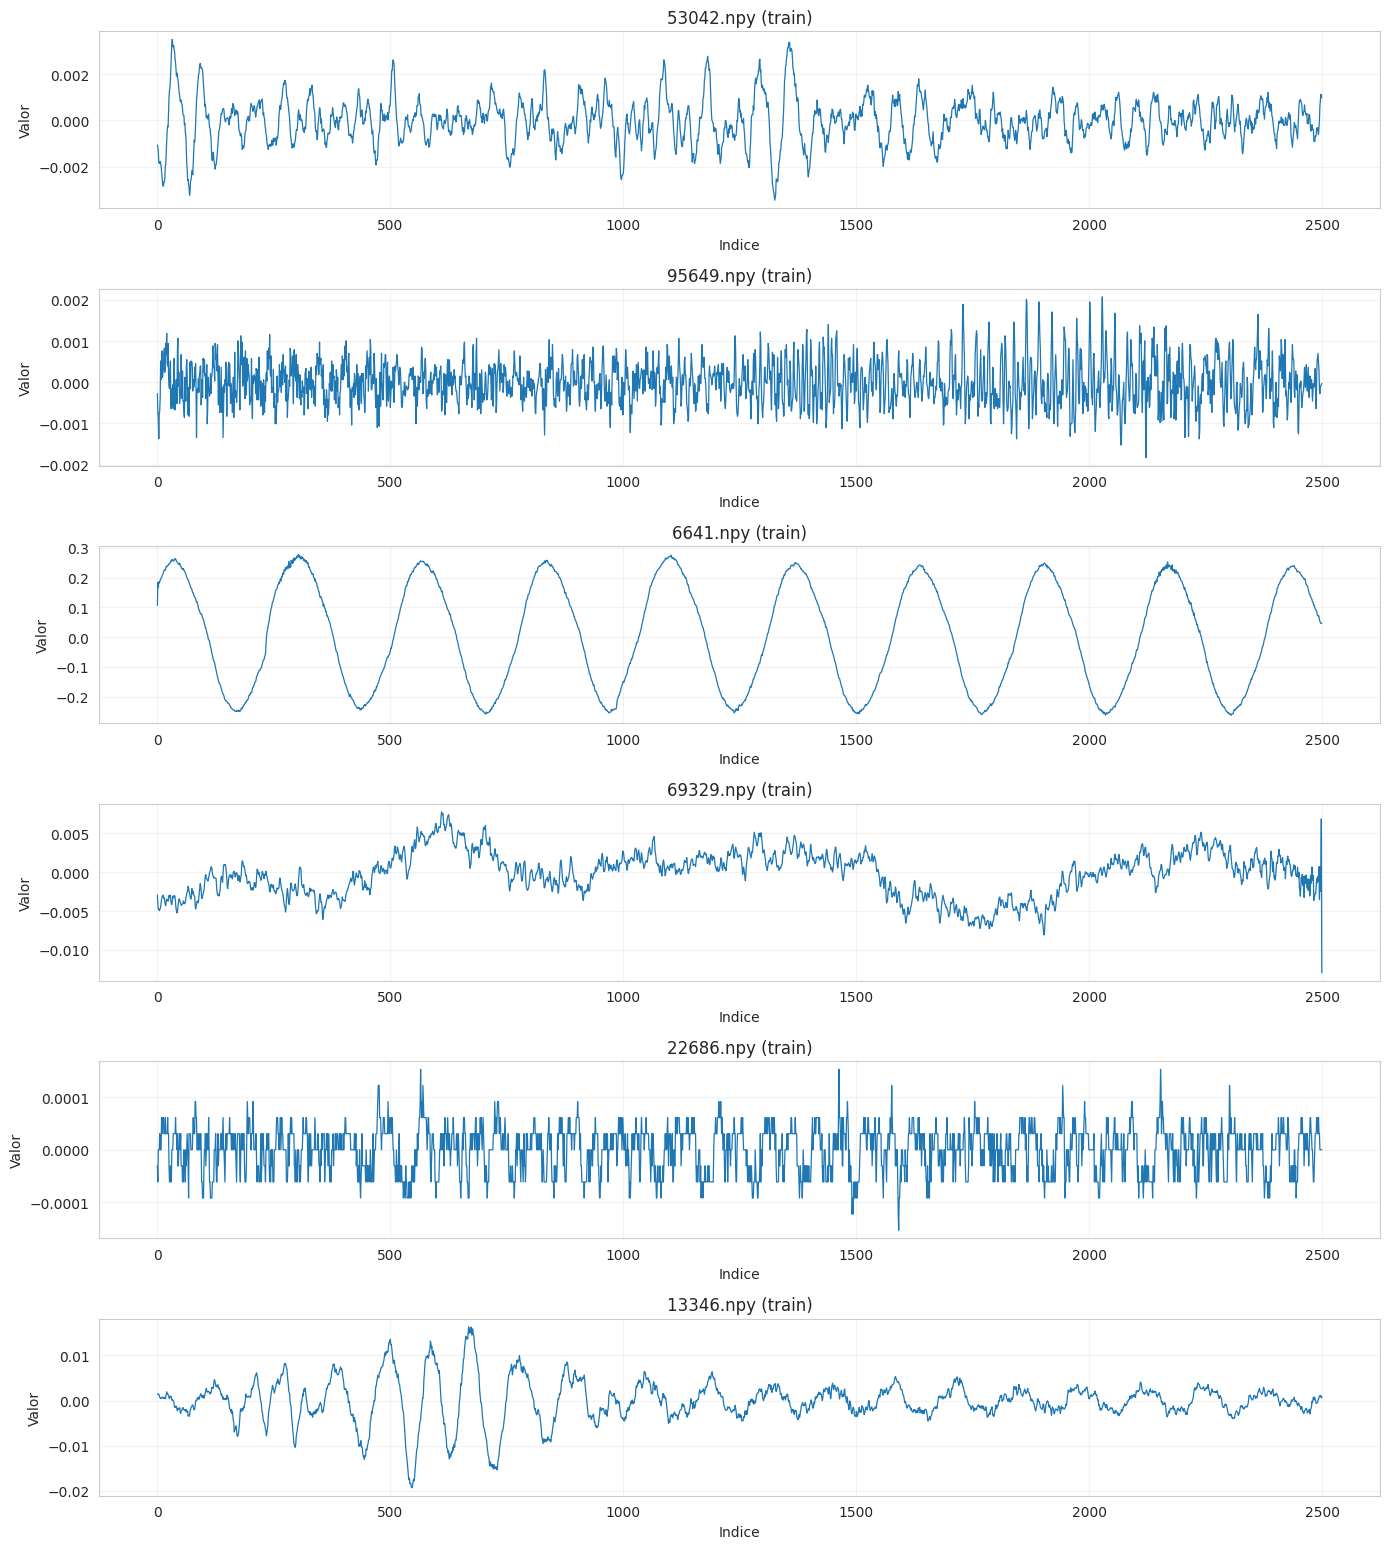

In [17]:
if len(train_df) > 0:
    print("\nVisualizacion de muestras .npy/.npz")
    print("=" * 60)

    np_ext = {'.npy', '.npz'}
    npy_rows = train_df[train_df['extension'].isin(np_ext)].head(6)

    if len(npy_rows) == 0:
        print("No se encontraron archivos visualizables.")
    else:
        fig, axes = plt.subplots(len(npy_rows), 1, figsize=(14, 2.6 * len(npy_rows)))
        if len(npy_rows) == 1:
            axes = [axes]

        for ax, (_, row) in zip(axes, npy_rows.iterrows()):
            arr = np.load(row['file_path'], allow_pickle=False)
            if isinstance(arr, np.lib.npyio.NpzFile):
                key = 'audio' if 'audio' in arr.files else arr.files[0]
                arr = arr[key]

            arr = np.asarray(arr)
            flat = arr.reshape(-1)
            n = min(2500, len(flat))
            ax.plot(flat[:n], linewidth=0.9)
            ax.set_title(f"{row['filename']} ({row['class']})")
            ax.set_xlabel("Indice")
            ax.set_ylabel("Valor")
            ax.grid(alpha=0.25)

        plt.tight_layout()
        plt.show()

## 5. Análisis de Distribución de Clases

ANALISIS DE DISTRIBUCION DE CLASES

Total de clases: 1
Total de muestras: 95246

Top clases:
class
train    95246
Name: count, dtype: int64

ESTADISTICAS DE BALANCE:
- Clase mas frecuente: train (95246 muestras)
- Clase menos frecuente: train (95246 muestras)
- Ratio desbalance: 1.00x
- Media por clase: 95246.0
- Desv. estandar por clase: nan


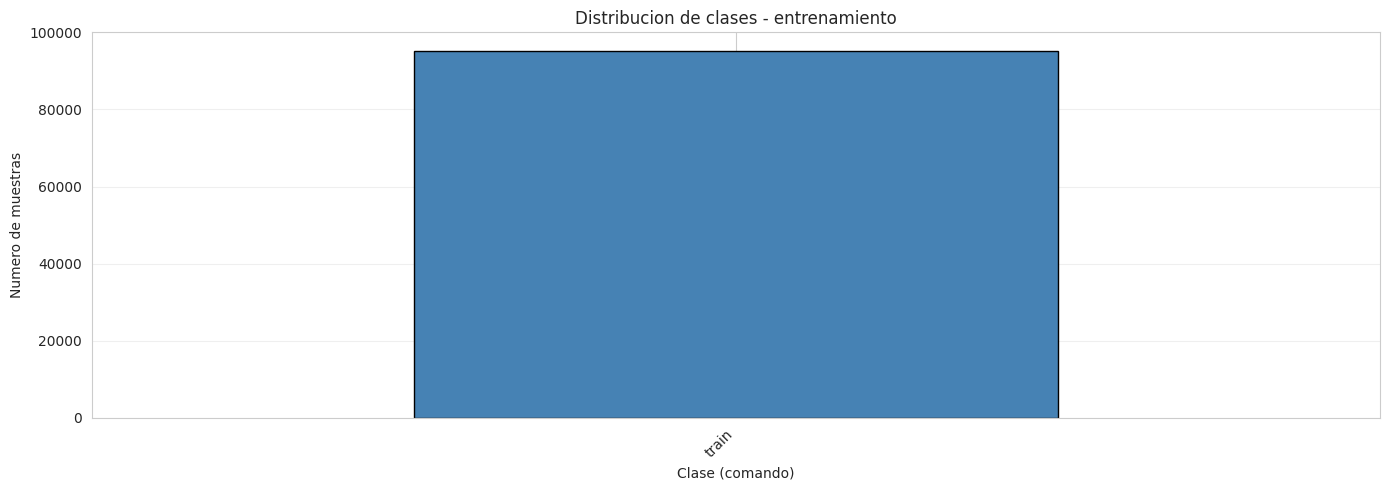

In [18]:
if len(train_df) > 0:
    print("=" * 60)
    print("ANALISIS DE DISTRIBUCION DE CLASES")
    print("=" * 60)

    class_counts = train_df['class'].value_counts().sort_values(ascending=False)

    print(f"\nTotal de clases: {len(class_counts)}")
    print(f"Total de muestras: {len(train_df)}")
    print("\nTop clases:")
    print(class_counts.head(10))

    imbalance_ratio = class_counts.iloc[0] / class_counts.iloc[-1]
    print("\nESTADISTICAS DE BALANCE:")
    print(f"- Clase mas frecuente: {class_counts.index[0]} ({class_counts.iloc[0]} muestras)")
    print(f"- Clase menos frecuente: {class_counts.index[-1]} ({class_counts.iloc[-1]} muestras)")
    print(f"- Ratio desbalance: {imbalance_ratio:.2f}x")
    print(f"- Media por clase: {class_counts.mean():.1f}")
    print(f"- Desv. estandar por clase: {class_counts.std():.1f}")

    plt.figure(figsize=(14, 5))
    class_counts.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.xlabel('Clase (comando)')
    plt.ylabel('Numero de muestras')
    plt.title('Distribucion de clases - entrenamiento')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()